C:\Users\schur\AppData\Local\Temp\ipykernel_6228\1424262690.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_transformed = df_transformed.replace(mapdict)


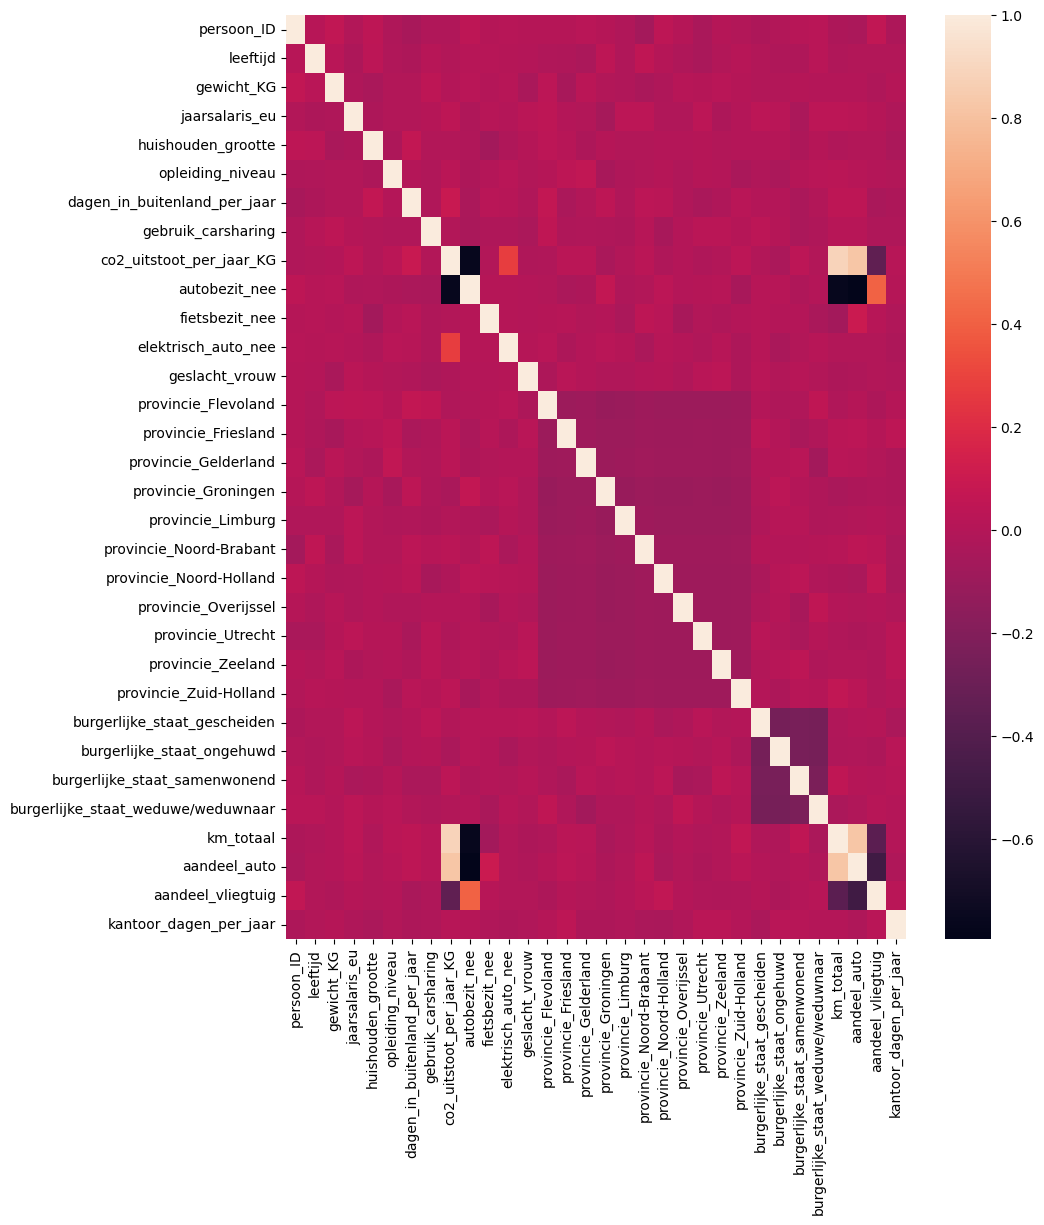

Mean Absolute Error: 625.45 KG CO2 per jaar
De b0 waarde van de formule is: -5569.02551980061
De coëfficiënten van de formule zijn: [ 2.18452895e-04  8.51238507e-01  2.00888636e+00  9.77967339e-04
  3.52158102e+00 -1.13034736e+01  1.74848372e+01 -5.61615601e+01
  1.74980900e+03  2.13023727e+02  2.61470226e+03  4.90005858e+01
  5.71598728e+01  2.33149892e+02  1.84203883e+02  6.92439751e+01
  1.16587996e+02  2.95698458e+02  2.60474075e+01  1.59058149e+02
  9.12849002e+01  1.34299377e+02 -5.24658789e+01 -4.80150547e+00
 -1.14626519e+02 -7.77026498e+01  9.71863004e+00  3.31788589e-01
  4.73481104e+03  5.57553119e+02  1.30007000e+00]
Voorspelling: 845.10 KG CO2 per jaar


In [645]:
%run Wiskunde_II_Portfolio.ipynb

In [646]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [647]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 200)

In [648]:
df_transformed

,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,opleiding_niveau,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG,autobezit_nee,fietsbezit_nee,elektrisch_auto_nee,geslacht_vrouw,provincie_Flevoland,provincie_Friesland,provincie_Gelderland,provincie_Groningen,provincie_Limburg,provincie_Noord-Brabant,provincie_Noord-Holland,provincie_Overijssel,provincie_Utrecht,provincie_Zeeland,provincie_Zuid-Holland,burgerlijke_staat_gescheiden,burgerlijke_staat_ongehuwd,burgerlijke_staat_samenwonend,burgerlijke_staat_weduwe/weduwnaar,km_totaal,aandeel_auto,aandeel_vliegtuig,kantoor_dagen_per_jaar
0,811069,50,52.66,48003.64,5,1,20,1,7591.93,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,19015.25,0.697653,0.025280,52
1,246882,65,64.58,55208.63,2,3,7,2,8742.25,False,True,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,18952.19,0.803595,0.075102,0
2,978385,49,90.87,29533.78,2,2,2,5,4513.56,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,26530.39,0.748321,0.023840,52
3,120468,34,80.43,44453.27,2,2,21,2,6904.41,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,17435.82,0.569833,0.072657,104
4,637034,60,72.28,56497.64,2,1,0,1,4420.80,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,21729.86,0.748586,0.077129,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,838823,78,85.84,28295.50,1,2,11,2,4251.29,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,14396.37,0.443392,0.087147,0
1496,964501,54,85.09,45963.45,5,1,3,2,4615.63,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,22113.02,0.816294,0.041020,52
1497,659695,48,71.79,43443.92,5,2,13,1,4631.48,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,10865.60,0.631394,0.127478,0
1498,883394,76,69.02,33158.29,4,1,15,1,786.82,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4513.83,0.000000,0.080809,0


In [649]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   persoon_ID                          1500 non-null   int64  
 1   leeftijd                            1500 non-null   int64  
 2   gewicht_KG                          1500 non-null   float64
 3   jaarsalaris_eu                      1500 non-null   float64
 4   huishouden_grootte                  1500 non-null   int64  
 5   opleiding_niveau                    1500 non-null   int64  
 6   dagen_in_buitenland_per_jaar        1500 non-null   int64  
 7   gebruik_carsharing                  1500 non-null   int64  
 8   co2_uitstoot_per_jaar_KG            1500 non-null   float64
 9   autobezit_nee                       1500 non-null   bool   
 10  fietsbezit_nee                      1500 non-null   bool   
 11  elektrisch_auto_nee                 1500 no

In [650]:
#feature_eng_cols = ['km_totaal', 'aandeel_auto', 'aandeel_vliegtuig', 'kantoor_dagen_per_jaar', 'hoog_uitstoot_gedrag']

#raw_eng_cols = ['km_auto_per_jaar', 'km_fiets_per_jaar', 'km_ov_per_jaar', 'km_vliegtuig_per_jaar', 'dagen_kantoorwerken_per_week_pro_rato']

#df_transformed = df_transformed.drop(raw_eng_cols, axis=1)

In [651]:
df_transformed[['autobezit_nee', 'km_totaal', 'aandeel_auto', 'aandeel_vliegtuig', 'co2_uitstoot_per_jaar_KG']].corr(method='spearman')

,autobezit_nee,km_totaal,aandeel_auto,aandeel_vliegtuig,co2_uitstoot_per_jaar_KG
autobezit_nee,1.000000,-0.766329,-0.794480,0.409728,-0.762259
km_totaal,-0.766329,1.000000,0.817933,-0.367069,0.885277
aandeel_auto,-0.794480,0.817933,1.000000,-0.490668,0.822021
aandeel_vliegtuig,0.409728,-0.367069,-0.490668,1.000000,-0.349888
co2_uitstoot_per_jaar_KG,-0.762259,0.885277,0.822021,-0.349888,1.000000


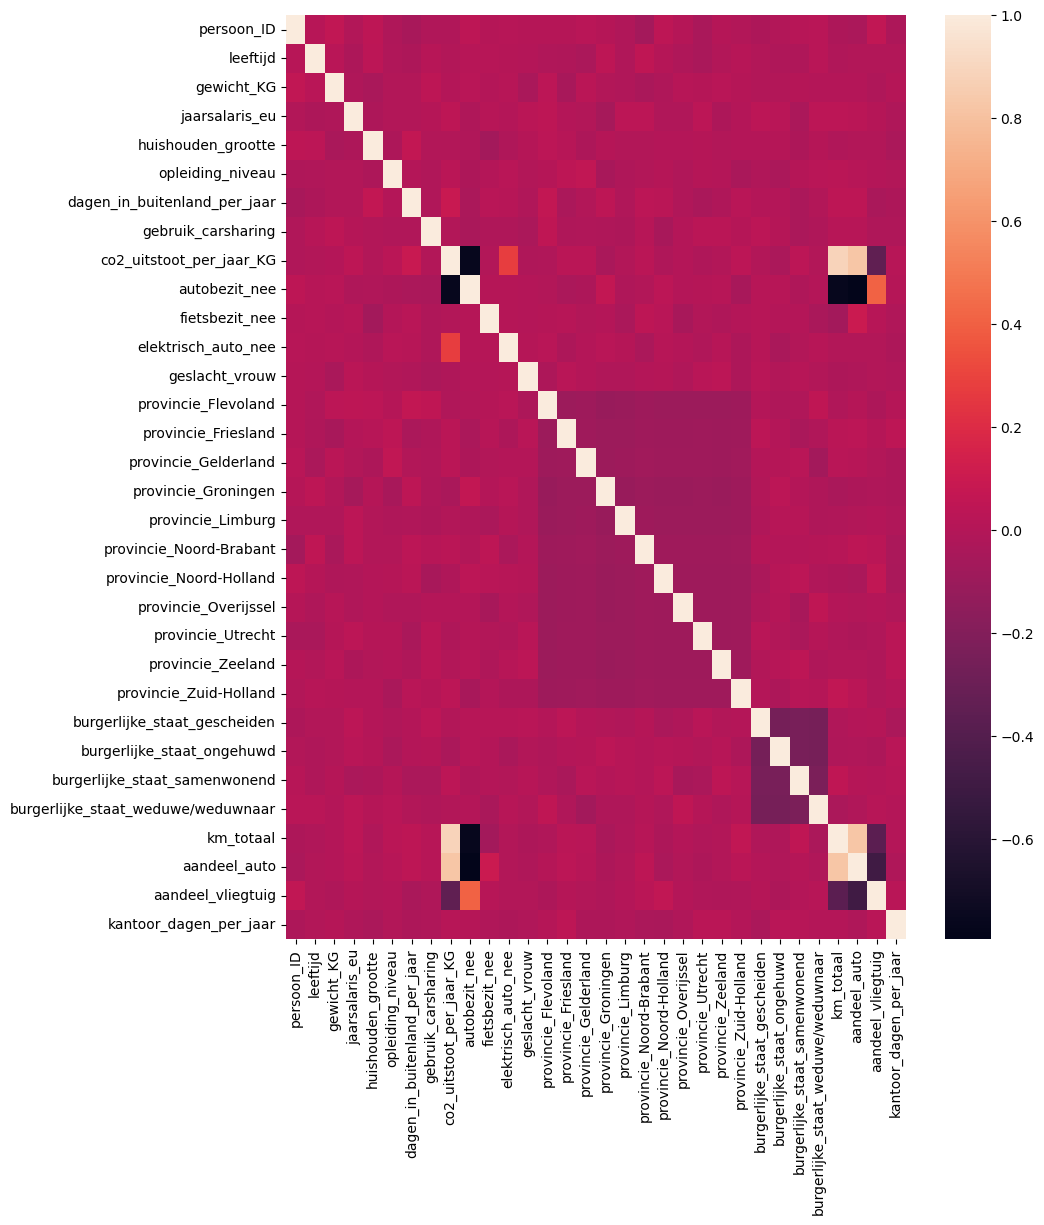

In [652]:
plt.figure(figsize=(10, 12))

sns.heatmap(df_transformed.corr(method='spearman'))

plt.show()

In [653]:
df[modus_cols]


,geslacht,burgerlijke_staat,provincie,opleiding_niveau,autobezit,fietsbezit,elektrisch_auto,gebruik_carsharing
0,man,weduwe/weduwnaar,Flevoland,MBO,ja,ja,nee,Nooit
1,vrouw,samenwonend,Overijssel,WO,ja,nee,nee,Heel soms
2,man,samenwonend,Utrecht,HBO,ja,ja,ja,Altijd
3,man,gehuwd,Utrecht,HBO,ja,ja,nee,Heel soms
4,man,ongehuwd,Gelderland,MBO,ja,ja,ja,Nooit
...,...,...,...,...,...,...,...,...
1495,man,weduwe/weduwnaar,Noord-Holland,HBO,ja,ja,nee,Heel soms
1496,man,ongehuwd,Drenthe,MBO,ja,ja,ja,Heel soms
1497,man,weduwe/weduwnaar,Flevoland,HBO,ja,ja,nee,Nooit
1498,man,gehuwd,Drenthe,MBO,nee,ja,nee,Nooit


In [654]:
import numpy as np

modus_cols = ['geslacht', 'burgerlijke_staat', 'provincie', 'opleiding_niveau', 'autobezit', 'fietsbezit', 'elektrisch_auto', 'gebruik_carsharing']

def eta_squared(categorisch, numeriek):
    groepen = [numeriek[categorisch == c] for c in categorisch.unique()]
    grand_mean = numeriek.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groepen)
    ss_total = ((numeriek - grand_mean)**2).sum()
    return ss_between / ss_total

for i in modus_cols:

    print(eta_squared(df[i], df['co2_uitstoot_per_jaar_KG']))


0.0008489676611990393
0.0022113464361503206
0.005266225248031182
0.0021808560349749003
0.5034053830760082
7.53412339514707e-06
0.09018871376382136
0.0032242970587868084


<Axes: >

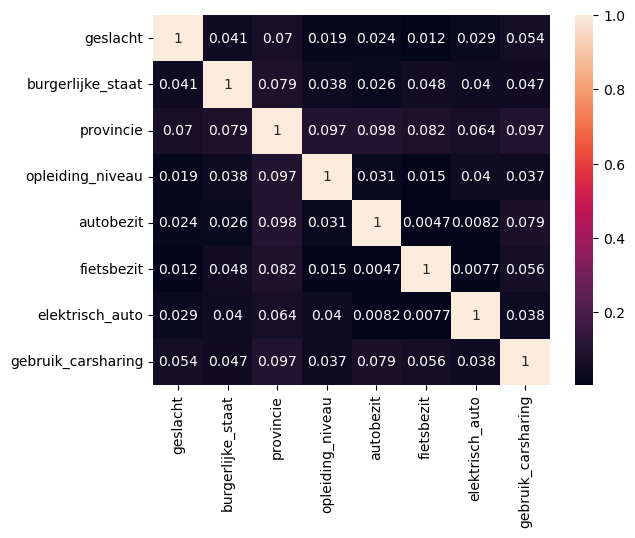

In [655]:
from scipy import stats
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.values.sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

dicto = {}

for i in modus_cols:
    dicto[i] = {}


    for j in modus_cols:

        dicto[i][j] = cramers_v(df[i], df[j])
        

        

dicto = pd.DataFrame(dicto)

sns.heatmap(dicto, annot=True)

In [656]:
corr_target

,aandeel_auto
aandeel_auto,1.000000
km_totaal,0.851292
co2_uitstoot_per_jaar_KG,0.809733
fietsbezit_nee,0.049531
gebruik_carsharing,0.045588
dagen_in_buitenland_per_jaar,0.043289
provincie_Zuid-Holland,0.041351
provincie_Friesland,0.036109
jaarsalaris_eu,0.035379
opleiding_niveau,0.024377


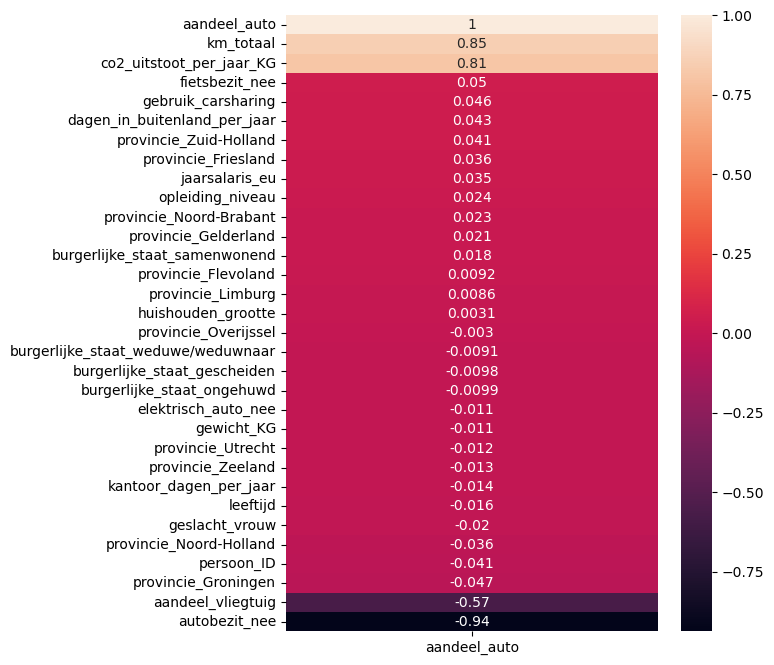

In [657]:
corr_target = df_transformed.corrwith(df_transformed['aandeel_auto']).sort_values(ascending=False).to_frame(name='aandeel_auto')

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True)

plt.show()

In [658]:
X = df_transformed.drop(['co2_uitstoot_per_jaar_KG', 'persoon_ID'], axis=1)
y = df_transformed['co2_uitstoot_per_jaar_KG']


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42, test_size=0.25)





In [659]:
from sklearn.linear_model import LinearRegression


In [660]:
#0.7313605259530767 - 

In [661]:
X_train

,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,opleiding_niveau,dagen_in_buitenland_per_jaar,gebruik_carsharing,autobezit_nee,fietsbezit_nee,elektrisch_auto_nee,geslacht_vrouw,provincie_Flevoland,provincie_Friesland,provincie_Gelderland,provincie_Groningen,provincie_Limburg,provincie_Noord-Brabant,provincie_Noord-Holland,provincie_Overijssel,provincie_Utrecht,provincie_Zeeland,provincie_Zuid-Holland,burgerlijke_staat_gescheiden,burgerlijke_staat_ongehuwd,burgerlijke_staat_samenwonend,burgerlijke_staat_weduwe/weduwnaar,km_totaal,aandeel_auto,aandeel_vliegtuig,kantoor_dagen_per_jaar
1132,72,75.10,42243.82,3,1,9,1,True,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,6144.90,0.000000,0.206111,208
1443,62,87.19,33621.34,2,1,18,2,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,5111.41,0.000000,0.000000,260
117,74,83.07,26808.59,5,3,17,2,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,23514.32,0.800690,0.000000,260
1077,29,74.81,60326.93,2,1,13,1,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,17539.70,0.814773,0.017628,260
1364,30,73.97,24889.81,4,1,12,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,21151.51,0.709819,0.111281,156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,56,81.78,31113.80,2,3,0,1,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,16360.87,0.795803,0.000000,260
530,78,75.32,34067.37,2,1,10,1,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,10290.28,0.736837,0.000000,208
139,18,68.73,27229.40,4,1,3,1,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,6483.54,0.401470,0.000000,0
1095,46,87.88,65776.49,2,2,16,1,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,16887.00,0.723182,0.034381,260


In [662]:
bool_cols = X_train.select_dtypes(include='bool').columns 

In [663]:
bool_cols

Index(['autobezit_nee', 'fietsbezit_nee', 'elektrisch_auto_nee',
       'geslacht_vrouw', 'provincie_Flevoland', 'provincie_Friesland',
       'provincie_Gelderland', 'provincie_Groningen', 'provincie_Limburg',
       'provincie_Noord-Brabant', 'provincie_Noord-Holland',
       'provincie_Overijssel', 'provincie_Utrecht', 'provincie_Zeeland',
       'provincie_Zuid-Holland', 'burgerlijke_staat_gescheiden',
       'burgerlijke_staat_ongehuwd', 'burgerlijke_staat_samenwonend',
       'burgerlijke_staat_weduwe/weduwnaar'],
      dtype='object')

In [665]:
X_train.columns

Index(['leeftijd', 'gewicht_KG', 'jaarsalaris_eu', 'huishouden_grootte',
       'opleiding_niveau', 'dagen_in_buitenland_per_jaar',
       'gebruik_carsharing', 'autobezit_nee', 'fietsbezit_nee',
       'elektrisch_auto_nee', 'geslacht_vrouw', 'provincie_Flevoland',
       'provincie_Friesland', 'provincie_Gelderland', 'provincie_Groningen',
       'provincie_Limburg', 'provincie_Noord-Brabant',
       'provincie_Noord-Holland', 'provincie_Overijssel', 'provincie_Utrecht',
       'provincie_Zeeland', 'provincie_Zuid-Holland',
       'burgerlijke_staat_gescheiden', 'burgerlijke_staat_ongehuwd',
       'burgerlijke_staat_samenwonend', 'burgerlijke_staat_weduwe/weduwnaar',
       'km_totaal', 'aandeel_auto', 'aandeel_vliegtuig',
       'kantoor_dagen_per_jaar'],
      dtype='object')

In [667]:
numerieke_cols = X_train.select_dtypes(exclude='bool').columns

scaler = StandardScaler()

X_train[mediaan_cols] = scaler.fit_transform(X_train[numerieke_cols])
X_val[mediaan_cols] = scaler.transform(X_val[numerieke_cols])
X_test[mediaan_cols] = scaler.transform(X_test[numerieke_cols])


In [668]:
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_val)

model.score(X_val, y_val)

0.8979095258643397

In [669]:
model.coef_

array([ 4.19184761e+01,  3.92135856e+01,  3.83264802e+01,  1.48636337e+03,
       -8.90434365e+00,  4.75929354e+01, -3.37561878e+01,  2.00625303e+03,
        6.03083452e+01,  2.75595269e+03,  1.89545828e+01,  8.84282276e+01,
        1.83548398e+02,  1.66086084e+02,  5.56393597e+01,  1.00529804e+02,
        1.94249699e+02,  4.16621799e+01,  1.94042638e+02,  2.15842861e+02,
        1.71040807e+02, -1.40048654e+02,  4.33741610e+01, -4.30839960e+01,
       -1.19544847e+02,  1.67030908e+01,  3.19767093e-01,  4.60003607e+02,
        4.18521881e+00,  1.83096770e+00,  1.75670973e+01, -1.11836560e+01,
        1.63858854e+02, -2.76125256e+01,  4.44477389e-05,  2.12938701e-02])

In [ ]:
mediaan_cols

['leeftijd',
 'gewicht_KG',
 'jaarsalaris_eu',
 'km_auto_per_jaar',
 'km_fiets_per_jaar',
 'km_ov_per_jaar',
 'km_vliegtuig_per_jaar',
 'co2_uitstoot_per_jaar_KG',
 'huishouden_grootte',
 'dagen_in_buitenland_per_jaar',
 'dagen_kantoorwerken_per_week_pro_rato']

In [ ]:
print('hallo')
_

hallo


['leeftijd',
 'gewicht_KG',
 'jaarsalaris_eu',
 'km_auto_per_jaar',
 'km_fiets_per_jaar',
 'km_ov_per_jaar',
 'km_vliegtuig_per_jaar',
 'co2_uitstoot_per_jaar_KG',
 'huishouden_grootte',
 'dagen_in_buitenland_per_jaar',
 'dagen_kantoorwerken_per_week_pro_rato']

In [ ]:
mediaan_cols.remove('co2_uitstoot_per_jaar_KG')

scaler = StandardScaler()

X_train[mediaan_cols] = scaler.fit_transform(X_train[_])
X_val[mediaan_cols] = scaler.transform(X_val[_])
X_test[mediaan_cols] = scaler.transform(X_test[_])



KeyError: "['km_auto_per_jaar', 'km_fiets_per_jaar', 'km_ov_per_jaar', 'km_vliegtuig_per_jaar', 'dagen_kantoorwerken_per_week_pro_rato'] not in index"

In [ ]:
lr = LinearRegression()

model = lr.fit(X_train, y_train)
y_pred = model.predict(X_val)

model.score(X_test, y_test)

0.9267434474068802